### Л/р 4 
### ЛИНЕЙНЫЕ КЛАССИФИКАТОРЫ. 
### МЕТОД ОПОРНЫХ ВЕКТОРОВ

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict
from qpsolvers import solve_qp
from sklearn import svm
from helpers import plot_decision_boundary, QPClassifier, kernel_matrix, KernelQPClassifier, compute_svm_errors_manual, compute_svm_errors_kernel

In [140]:
def generate_samples(M: np.ndarray, B: np.ndarray, n: int = 100) -> np.ndarray:
    return np.random.multivariate_normal(M, B, n)

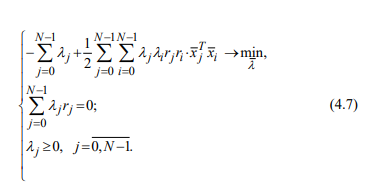

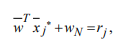

In [141]:
def solve_svm_primal_linear(X: np.ndarray, r: np.ndarray) -> Tuple[np.ndarray, float, np.ndarray]:
    N = X.shape[0]
    x_j_T_x_i = np.dot(X, X.T)
    P = np.outer(r, r) * x_j_T_x_i
    
    # -∑ λ_j
    q = -np.ones(N)
    
    # λ_j ≥ 0 => -λ_j ≤ 0
    G = -np.eye(N)
    h = np.zeros(N)
    
    # Ограничение равенства: A * λ = b
    # ∑ λ_j * r_j = 0
    A = r.reshape(1, -1).astype(float)
    b = np.array([0.0])
    
    lambda_vec = solve_qp(P, q, G, h, A, b, solver='cvxopt')
    epsilon = 1e-6
    support_indices = lambda_vec > epsilon
    w = np.sum(
        (lambda_vec[support_indices] * r[support_indices])[:, np.newaxis] * X[support_indices],
        axis=0
    )
    
    # Берем среднее по всем опорным векторам для устойчивости
    if np.any(support_indices):
        X_sv = X[support_indices]  # Опорные векторы
        r_sv = r[support_indices]  # Метки опорных векторов
        
        # Для каждого опорного вектора: w_N = r_j - w^T x_j
        w_N_values = r_sv - np.dot(X_sv, w)
        w_N = np.mean(w_N_values)
    else:
        w_N = 0.0
    
    return w, w_N, lambda_vec

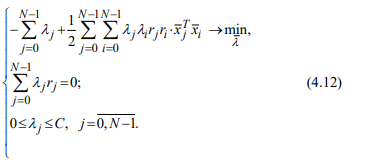

In [142]:
def solve_svm_soft_margin(X: np.ndarray, r: np.ndarray, C: float = 1.0) -> Tuple[np.ndarray, float, np.ndarray]:
    """
    Parameters:
    -----------
    X : np.ndarray
        Матрица признаков размером (N, d)
    r : np.ndarray
        Вектор меток классов (±1) размером N
    C : float
        Параметр регуляризации (штраф за ошибки)
    
    Returns:
    --------
    w : np.ndarray
        Вектор весов классификатора
    w_N : float
        Свободный член (порог)
    lambda_vec : np.ndarray
        Вектор двойственных переменных λ
    """
    N = X.shape[0]
    
    # x_j^T x_i для всех пар (формула внутри суммы)
    x_j_T_x_i = np.dot(X, X.T)
    
    # P = r_j * r_i * x_j^T * x_i (матрица квадратичной формы)
    P = np.outer(r, r) * x_j_T_x_i
    
    # q = -1 (коэффициенты при λ_j)
    q = -np.ones(N)
    
    # Ограничения: 0 ≤ λ_j ≤ C
    # В виде G * λ ≤ h:
    # 1) λ_j ≤ C => λ_j - C ≤ 0
    # 2) -λ_j ≤ 0 (λ_j ≥ 0)
    G = np.vstack([
        np.eye(N),    # λ_j ≤ C
        -np.eye(N)    # -λ_j ≤ 0
    ])
    h = np.hstack([
        C * np.ones(N),  # верхняя граница C
        np.zeros(N)      # нижняя граница 0
    ])
    
    # Ограничение равенства: ∑ λ_j * r_j = 0
    A = r.reshape(1, -1).astype(float)
    b = np.array([0.0])
    
    # Решение квадратичной задачи
    lambda_vec = solve_qp(P, q, G, h, A, b, solver='cvxopt')
    
    # Порог для определения опорных векторов
    epsilon = 1e-9
    support_indices = lambda_vec > epsilon
    
    # Вычисление вектора весов w по формуле (4.9): w = ∑ λ_j * r_j * x_j
    w = np.sum(
        (lambda_vec[support_indices] * r[support_indices])[:, np.newaxis] * X[support_indices],
        axis=0
    )
    
    # Вычисление свободного члена w_N
    # Используем свободные опорные векторы: 0 < λ_j < C
    free_support_indices = (lambda_vec > epsilon) & (lambda_vec < C - epsilon)
    
    if np.any(free_support_indices):
        X_free_sv = X[free_support_indices]
        r_free_sv = r[free_support_indices]
        # w_N = r_j - w^T * x_j для свободных опорных векторов
        w_N_values = r_free_sv - np.dot(X_free_sv, w)
        w_N = np.mean(w_N_values)
    else:
        # Если нет свободных опорных векторов, используем все опорные
        X_sv = X[support_indices]
        r_sv = r[support_indices]
        w_N_values = r_sv - np.dot(X_sv, w)
        w_N = np.mean(w_N_values)
    
    return w, w_N, lambda_vec

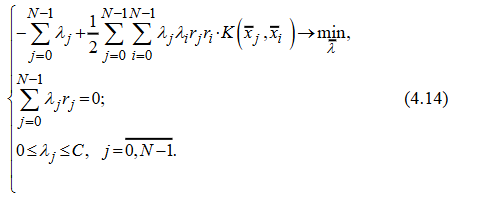

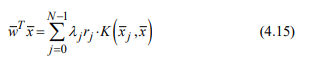

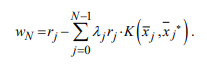

In [143]:
def solve_svm_kernel(X: np.ndarray, r: np.ndarray, C: float = 1.0, 
                     kernel_type: str = 'linear', **kernel_params) -> Tuple[np.ndarray, float, np.ndarray, Dict]:
    """
    Решение SVM с ядрами (формула 4.14 из методички).
    
    Parameters:
    -----------
    X : np.ndarray
        Матрица признаков размером (N, d)
    r : np.ndarray  
        Вектор меток классов (±1) размером N
    C : float
        Параметр регуляризации (штраф за ошибки)
    kernel_type : str
        Тип ядра: 'linear', 'poly', 'rbf', 'sigmoid'
    **kernel_params : 
        Параметры ядра (degree для poly, gamma для rbf/sigmoid, coef0 для sigmoid)
    
    Returns:
    --------
    w : np.ndarray
        Вектор весов (только для линейного ядра, иначе None)
    w_N : float
        Свободный член (порог)
    lambda_vec : np.ndarray
        Вектор двойственных переменных λ
    kernel_info : Dict
        Дополнительная информация для ядерного классификатора
    """
    N = X.shape[0]
    
    # Вычисляем матрицу ядра K(x̄_j, x̄_i) по таблице 4.1
    K = kernel_matrix(X, kernel_type, **kernel_params)
    
    # P = r_j * r_i * K(x̄_j, x̄_i) (матрица квадратичной формы)
    P = np.outer(r, r) * K
    
    # q = -1 (коэффициенты при λ_j)
    q = -np.ones(N)
    
    # Ограничения: 0 ≤ λ_j ≤ C
    G = np.vstack([
        np.eye(N),    # λ_j ≤ C
        -np.eye(N)    # -λ_j ≤ 0
    ])
    h = np.hstack([
        C * np.ones(N),  # верхняя граница C
        np.zeros(N)      # нижняя граница 0
    ])
    
    # Ограничение равенства: ∑ λ_j * r_j = 0
    A = r.reshape(1, -1).astype(float)
    b = np.array([0.0])
    
    # Решение квадратичной задачи
    lambda_vec = solve_qp(P, q, G, h, A, b, solver='cvxopt')
    
    # Порог для определения опорных векторов
    epsilon = 1e-6
    support_indices = lambda_vec > epsilon
    
    # Вычисление w только для линейного ядра (по формуле 4.9)
    w = None
    if kernel_type == 'linear':
        w = np.sum(
            (lambda_vec[support_indices] * r[support_indices])[:, np.newaxis] * X[support_indices],
            axis=0
        )
    
    # Вычисление свободного члена w_N
    # Используем свободные опорные векторы: 0 < λ_j < C
    free_support_indices = (lambda_vec > epsilon) & (lambda_vec < C - epsilon)
    
    if np.any(free_support_indices):
        # Берем первый свободный опорный вектор
        idx = free_support_indices.nonzero()[0][0]
        # w_N = r_j - ∑_{i=0}^{N-1} λ_i * r_i * K(x̄_i, x̄_j)
        kernel_sum = np.sum(lambda_vec[support_indices] * r[support_indices] * K[idx, support_indices])
        w_N = r[idx] - kernel_sum
    else:
        # Используем все опорные векторы
        support_idx = support_indices.nonzero()[0][0] if np.any(support_indices) else 0
        kernel_sum = np.sum(lambda_vec[support_indices] * r[support_indices] * K[support_idx, support_indices])
        w_N = r[support_idx] - kernel_sum if np.any(support_indices) else 0.0
    
    kernel_info = {
        'kernel_type': kernel_type,
        'kernel_params': kernel_params,
        'X_train': X,
        'r_train': r,
        'lambda_vec': lambda_vec,
        'support_indices': support_indices,
        'K_matrix': K
    }
    
    return w, w_N, lambda_vec, kernel_info

In [144]:
M1 = np.array([1.5, 1.5])
M2 = np.array([-1.5, -1.5])

B1 = np.array([[0.2, -0.1],
               [-0.1, 0.4]])

B2 = np.array([[0.4, -0.2],
               [-0.2, 0.4]])

n_samples = 100

#### Линейно разделимые выборки

#### 1. Генерация выборок

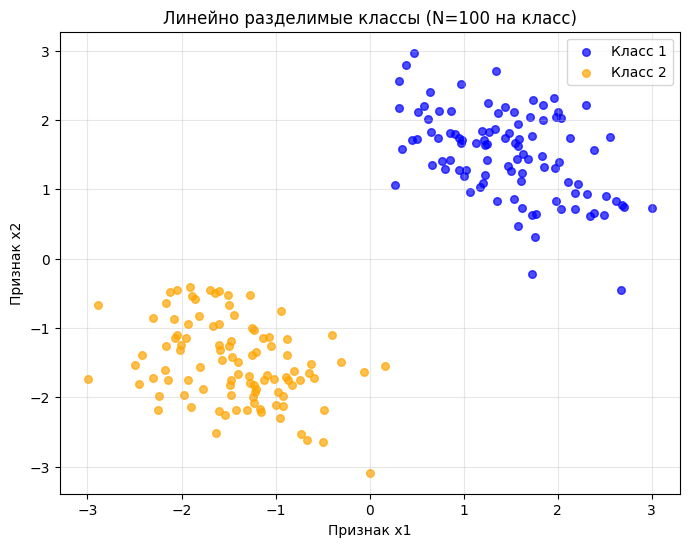

In [145]:
X1_linear = generate_samples(M1, B2, n_samples)  # +1
X2_linear = generate_samples(M2, B2, n_samples)  # -1

X_linear = np.vstack([X1_linear, X2_linear])
y_linear = np.hstack([np.ones(n_samples), -np.ones(n_samples)])

plt.figure(figsize=(8, 6))
plt.scatter(X1_linear[:, 0], X1_linear[:, 1], s=30, alpha=0.7, 
           label='Класс 1', color='blue')
plt.scatter(X2_linear[:, 0], X2_linear[:, 1], s=30, alpha=0.7, 
           label='Класс 2', color='orange')
plt.title('Линейно разделимые классы (N=100 на класс)')
plt.xlabel('Признак x1')
plt.ylabel('Признак x2')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### 2. SVM ДЛЯ ЛИНЕЙНО РАЗДЕЛИМЫХ КЛАССОВ

In [146]:
w_qp, b_qp, alpha_qp = solve_svm_primal_linear(X_linear, y_linear)

svc_clf = svm.SVC(kernel='linear', C=1e6)
svc_clf.fit(X_linear, y_linear)

linear_svc_clf = svm.LinearSVC(C=1e6, dual=True, max_iter=10000)
linear_svc_clf.fit(X_linear, y_linear)

,penalty,'l2'
,loss,'squared_hinge'
,dual,True
,tol,0.0001
,C,1000000.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


Ошибки QP-классификатор: (0.86, 0.14)
Ошибки SVC: (0.86, 0.14)
Ошибки LinearSVC: (0.86, 0.14)


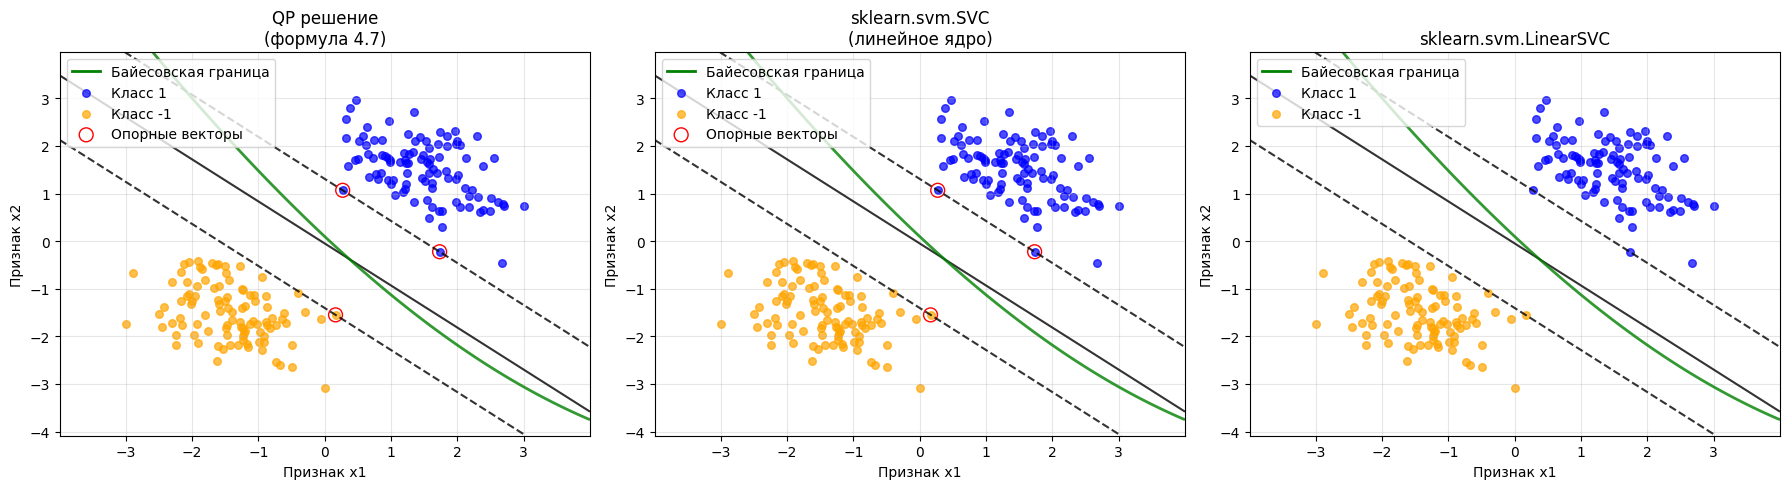

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

qp_clf = QPClassifier(w_qp, b_qp, X_train=X_linear, lambda_vec=alpha_qp)

plot_decision_boundary(X_linear, y_linear, qp_clf, 
                      "QP решение\n(формула 4.7)", axes[0], bayes_params = {
    "M1": M1,
    "M2": M2,
    "B1": B1,
    "B2": B2
})
plot_decision_boundary(X_linear, y_linear, svc_clf, 
                      "sklearn.svm.SVC\n(линейное ядро)", axes[1], bayes_params = {
    "M1": M1,
    "M2": M2,
    "B1": B1,
    "B2": B2
})
plot_decision_boundary(X_linear, y_linear, linear_svc_clf, 
                      "sklearn.svm.LinearSVC", axes[2], bayes_params = {
    "M1": M1,
    "M2": M2,
    "B1": B1,
    "B2": B2
})

plt.tight_layout()

err_qp = compute_svm_errors_manual(X1_linear, X2_linear, w_qp, b_qp)
err_svc = compute_svm_errors_manual(X1_linear, X2_linear, svc_clf.coef_.flatten(), svc_clf.intercept_[0])
err_linear_svc = compute_svm_errors_manual(X1_linear, X2_linear, linear_svc_clf.coef_.flatten(), linear_svc_clf.intercept_[0])

print("Ошибки QP-классификатор:", err_qp)
print("Ошибки SVC:", err_svc)
print("Ошибки LinearSVC:", err_linear_svc)

plt.show()

#### Линейно НЕ разделимые выборки

In [148]:
# 3 вариант
M1 = np.array([0.5, 0.5])
M2 = np.array([-0.7, -0.7])

B1 = np.array([[0.2, -0.1],
               [-0.1, 0.4]])

B2 = np.array([[0.4, -0.2],
               [-0.2, 0.4]])

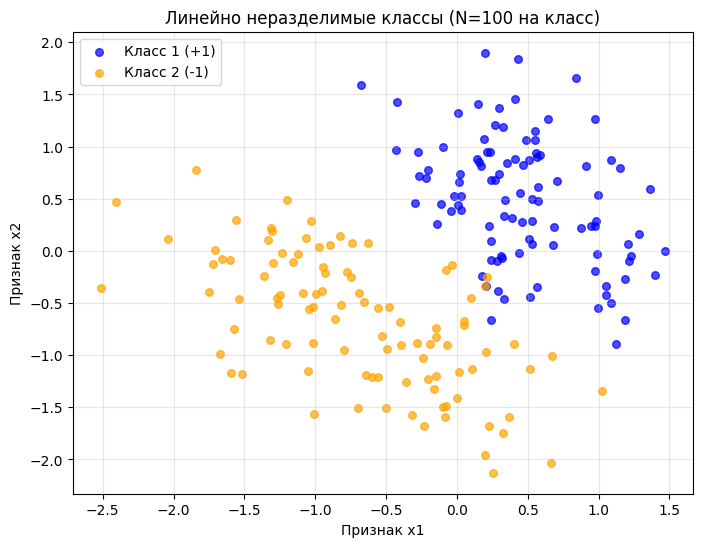

In [149]:
X1_nonlinear = generate_samples(M1, B1, n_samples)
X2_nonlinear = generate_samples(M2, B2, n_samples)

X_nonlinear = np.vstack([X1_nonlinear, X2_nonlinear])
y_nonlinear = np.hstack([np.ones(n_samples), -np.ones(n_samples)])

plt.figure(figsize=(8, 6))
plt.scatter(X1_nonlinear[:, 0], X1_nonlinear[:, 1], s=30, alpha=0.7, 
           label='Класс 1 (+1)', color='blue')
plt.scatter(X2_nonlinear[:, 0], X2_nonlinear[:, 1], s=30, alpha=0.7, 
           label='Класс 2 (-1)', color='orange')
plt.title('Линейно неразделимые классы (N=100 на класс)')
plt.xlabel('Признак x1')
plt.ylabel('Признак x2')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [150]:
C_values = [0.1, 1.0, 10.0]
results_qp = {}
for C in C_values:
    w, b, alpha = solve_svm_soft_margin(X_nonlinear, y_nonlinear, C)
    results_qp[C] = (w, b, alpha)
    
    err_qp = compute_svm_errors_manual(X1_nonlinear, X2_nonlinear, w, b)
    print(f"Ошибки QP-классификатор (c = {C}):", err_qp)

results_sklearn = {}
for C in C_values:
    clf = svm.SVC(kernel='linear', C=C)
    clf.fit(X_nonlinear, y_nonlinear)
    results_sklearn[C] = clf
    err_svc = compute_svm_errors_manual(X1_nonlinear, X2_nonlinear, clf.coef_.flatten(), clf.intercept_[0])
    print(f"Ошибки SVC (c = {C}):", err_svc)

Ошибки QP-классификатор (c = 0.1): (0.93, 0.21)
Ошибки QP-классификатор (c = 1.0): (0.95, 0.08)
Ошибки QP-классификатор (c = 10.0): (0.97, 0.04)
Ошибки SVC (c = 0.1): (0.92, 0.21)
Ошибки SVC (c = 1.0): (0.96, 0.07)
Ошибки SVC (c = 10.0): (0.96, 0.04)


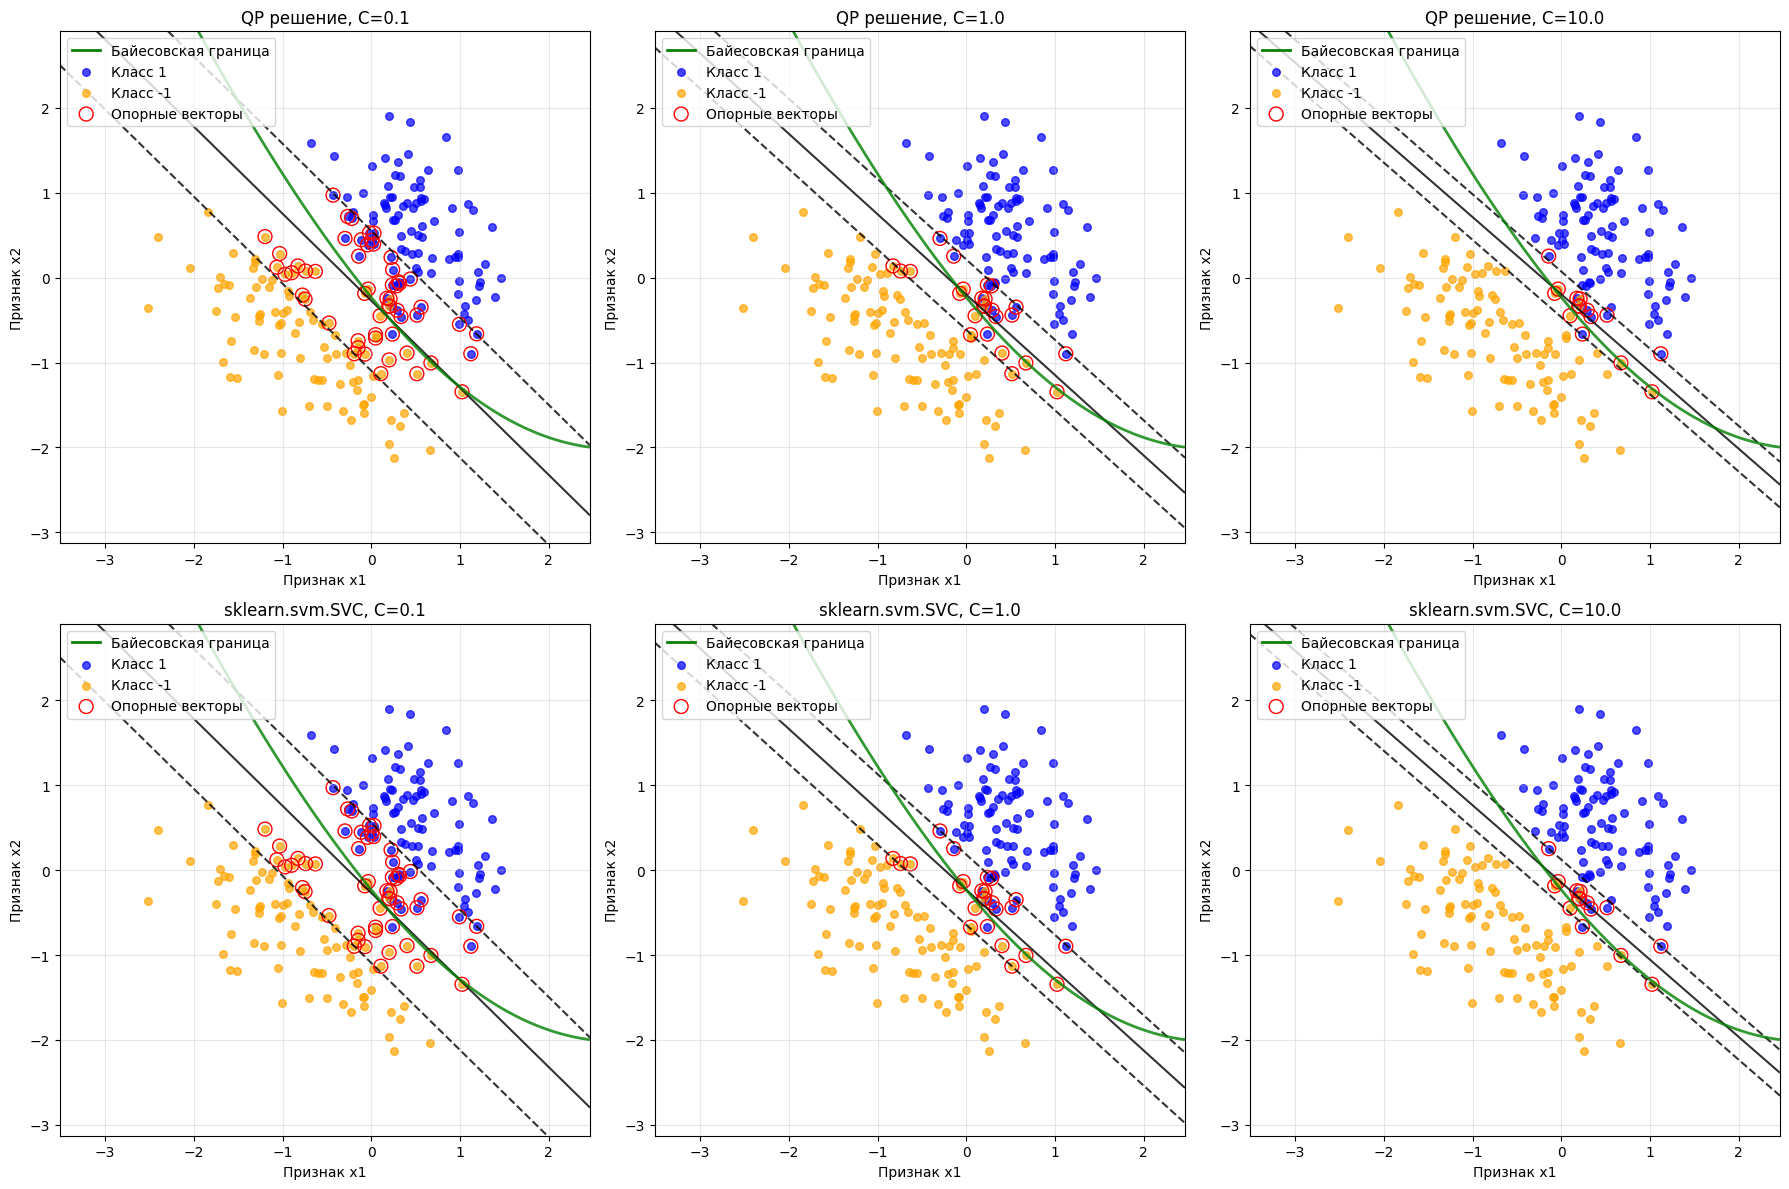

In [151]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, C in enumerate(C_values):
    # QP решение
    w, b, alpha = results_qp[C]
    qp_clf = QPClassifier(w, b, X_train=X_nonlinear, lambda_vec=alpha)
    
    ax = axes[0, idx]
    plot_decision_boundary(X_nonlinear, y_nonlinear, qp_clf,
                          f"QP решение, C={C}", ax, bayes_params = {
        "M1": M1,
        "M2": M2,
        "B1": B1,
        "B2": B2
    })
    
    # Sklearn решение
    sk_clf = results_sklearn[C]
    ax = axes[1, idx]
    plot_decision_boundary(X_nonlinear, y_nonlinear, sk_clf,
                          f"sklearn.svm.SVC, C={C}", ax, bayes_params = {
        "M1": M1,
        "M2": M2,
        "B1": B1,
        "B2": B2
    })

plt.tight_layout()
plt.show()

#### N - размерные пространства

In [152]:
kernels_to_test = [
    {'type': 'linear', 'params': {}, 'name': 'Линейное'},
    {'type': 'poly', 'params': {'degree': 2}, 'name': 'Полиномиальное (d=2)'},
    {'type': 'poly', 'params': {'degree': 3}, 'name': 'Полиномиальное (d=3)'},
    {'type': 'rbf', 'params': {'gamma': 0.5}, 'name': 'RBF (gamma=0.5)'},
    {'type': 'rbf', 'params': {'gamma': 1.0}, 'name': 'RBF (gamma=1.0)'},
    {'type': 'sigmoid', 'params': {'gamma': 0.1, 'coef0': 0}, 'name': 'Сигмоидальное'},
]

C = 1.0
results_kernel_qp = {}

for kernel_info in kernels_to_test[:4]:  # Тестируем первые 4 ядра для наглядности
    result = solve_svm_kernel(X_nonlinear, y_nonlinear, C=C,
                             kernel_type=kernel_info['type'],
                             **kernel_info['params'])
    results_kernel_qp[kernel_info['name']] = result

sklearn_kernels = [
    {'kernel': 'linear', 'name': 'Линейное'},
    {'kernel': 'poly', 'degree': 2, 'name': 'Полиномиальное (d=2)'},
    {'kernel': 'poly', 'degree': 3, 'name': 'Полиномиальное (d=3)'},
    {'kernel': 'rbf', 'gamma': 0.5, 'name': 'RBF (gamma=0.5)'},
    {'kernel': 'rbf', 'gamma': 1.0, 'name': 'RBF (gamma=1.0)'},
    {'kernel': 'sigmoid', 'gamma': 0.1, 'coef0': 0, 'name': 'Сигмоидальное'},
]

results_kernel_sklearn = {}

for kernel_info in sklearn_kernels[:4]:  # Тестируем первые 4 ядра
    params = {k: v for k, v in kernel_info.items() if k != 'name'}
    clf = svm.SVC(C=C, **params)
    clf.fit(X_nonlinear, y_nonlinear)
    results_kernel_sklearn[kernel_info['name']] = clf

QP
Линейное: ошибки [+1] = 0.050, [-1] = 0.000
Полиномиальное (d=2): ошибки [+1] = 0.050, [-1] = 0.000
Полиномиальное (d=3): ошибки [+1] = 0.050, [-1] = 0.000
RBF (gamma=0.5): ошибки [+1] = 0.010, [-1] = 0.040
sklearn
Линейное: ошибки [+1] = 0.010, [-1] = 0.030
Полиномиальное (d=2): ошибки [+1] = 0.260, [-1] = 0.440
Полиномиальное (d=3): ошибки [+1] = 0.000, [-1] = 0.070
RBF (gamma=0.5): ошибки [+1] = 0.010, [-1] = 0.030


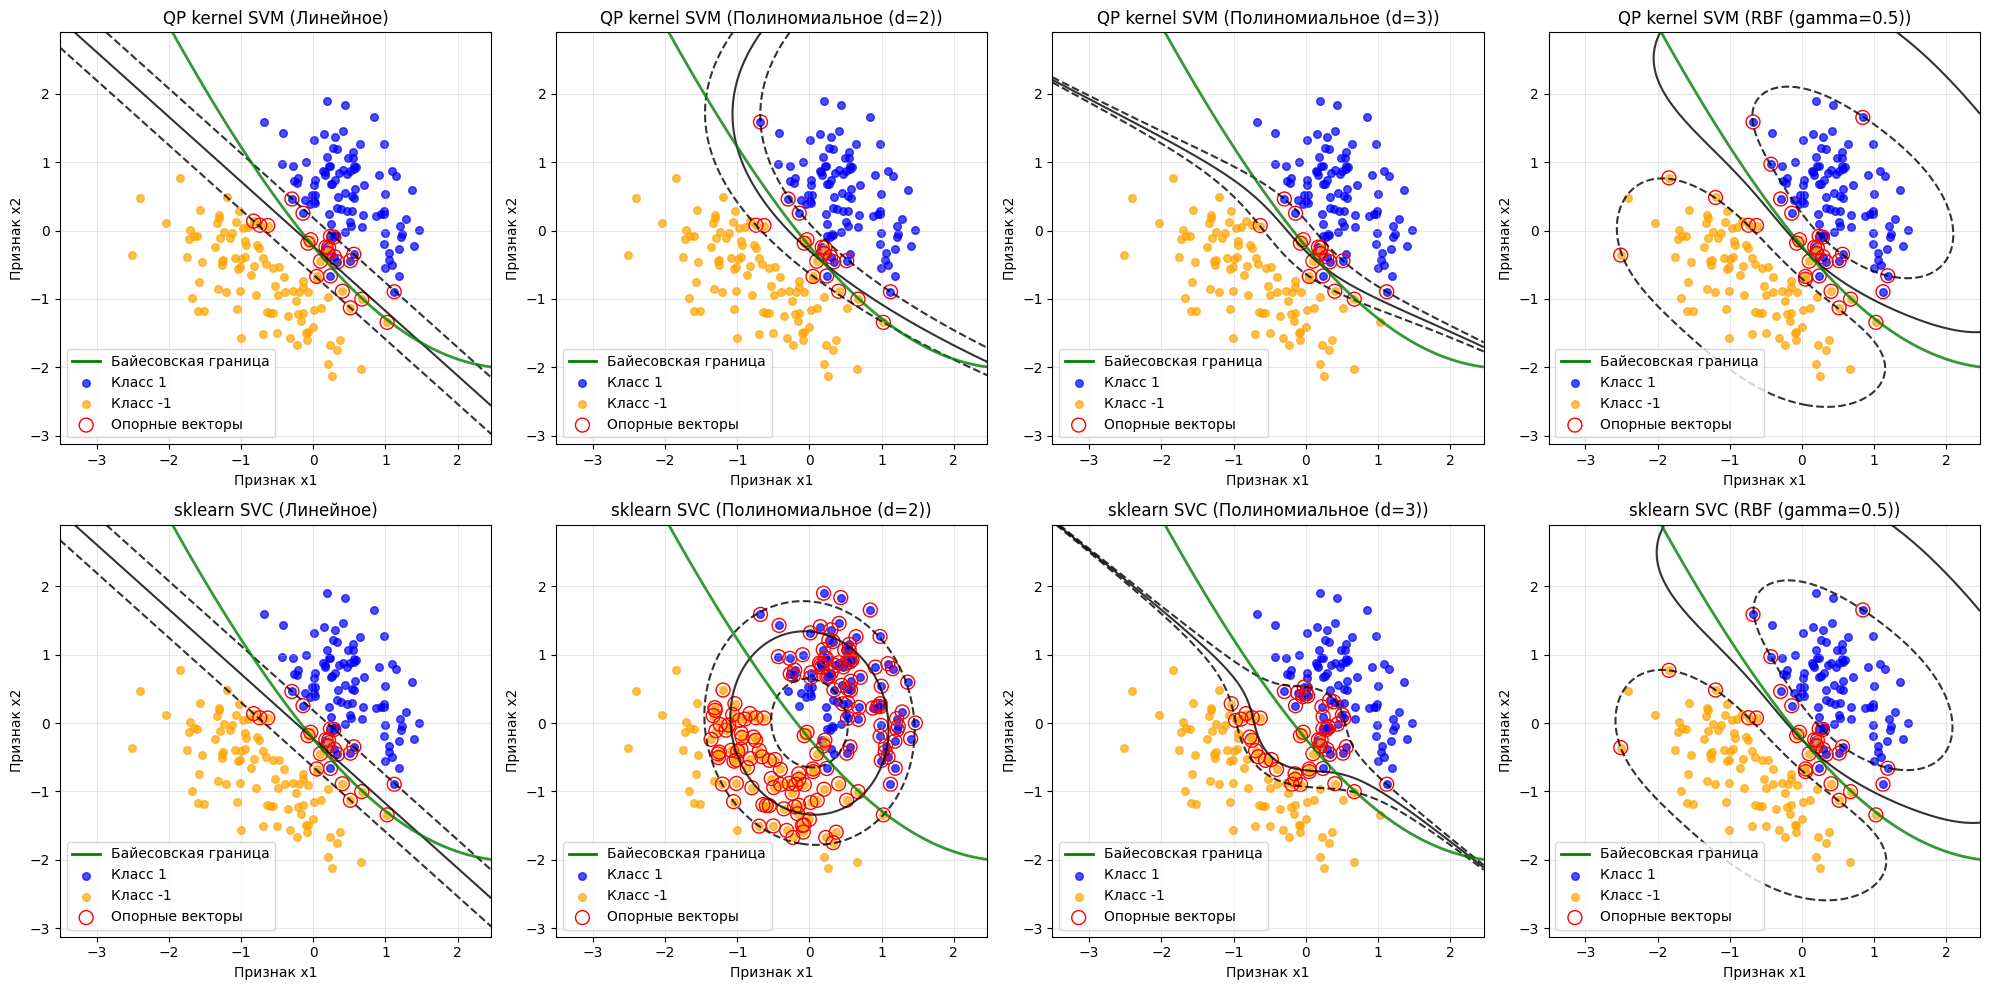

In [153]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

print("QP")
for idx, (name, result) in enumerate(results_kernel_qp.items()):
    w, b, lambda_vec, kernel_info = result
    qp_clf = KernelQPClassifier(b, kernel_info)

    err_I, err_II = compute_svm_errors_kernel(X1_nonlinear, X2_nonlinear, kernel_info)
    print(f"{name}: ошибки [+1] = {err_I:.3f}, [-1] = {err_II:.3f}")

    ax = axes[0, idx]
    plot_decision_boundary(X_nonlinear, y_nonlinear, qp_clf,
                           f"QP kernel SVM ({name})", ax, bayes_params = {
        "M1": M1,
        "M2": M2,
        "B1": B1,
        "B2": B2
    })
    

print("sklearn")
for idx, (name, clf) in enumerate(results_kernel_sklearn.items()):
    ax = axes[1, idx]
    # Класс +1
    pred_X1 = clf.predict(X1_nonlinear)
    err_I = np.sum(pred_X1 != 1) / len(X1_nonlinear)
    
    # Класс -1
    pred_X2 = clf.predict(X2_nonlinear)
    err_II = np.sum(pred_X2 != -1) / len(X2_nonlinear)
    
    print(f"{name}: ошибки [+1] = {err_I:.3f}, [-1] = {err_II:.3f}")

    plot_decision_boundary(X_nonlinear, y_nonlinear, clf,
                           f"sklearn SVC ({name})", ax, bayes_params = {
        "M1": M1,
        "M2": M2,
        "B1": B1,
        "B2": B2
    })

plt.tight_layout()
plt.show()
